In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/14986.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/3138.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/1700.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/16257.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/2863.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/771.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/12167.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/17643.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/6560.jpg
/kaggle/input/datasets/puneet6060/intel-image-classification/seg_train/seg_train/mountain/10162.jpg
/kaggl

In [2]:
os.makedirs("outputs", exist_ok=True)

import torch
import torchvision
from torchvision import models, transforms
from torchvision.models import ResNet18_Weights
from PIL import Image
import matplotlib.pyplot as plt
import time
from pathlib import Path
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")
print(f"TorchVision version: {torchvision.__version__}")

Using device: cuda
PyTorch version: 2.10.0+cu128
TorchVision version: 0.25.0+cu128


PyTorch Tensors

Q1

In [3]:
a = torch.tensor([[ 1.0, 2.0, 3.0],
                 [4.0, 5.0, 6.0]])

b = torch.zeros(2,3)
c = torch.ones(4)

for name, t in [("a", a), ("b", b), ("c", c)]:
    print(f"{name} =\n{t}")
    print(f"shape: {t.shape}")
    print(f"dtype: {t.dtype}")
    print(f"device: {t.device}")
    print("-" * 40)

a =
tensor([[1., 2., 3.],
        [4., 5., 6.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu
----------------------------------------
b =
tensor([[0., 0., 0.],
        [0., 0., 0.]])
shape: torch.Size([2, 3])
dtype: torch.float32
device: cpu
----------------------------------------
c =
tensor([1., 1., 1., 1.])
shape: torch.Size([4])
dtype: torch.float32
device: cpu
----------------------------------------


These tensors on all on CPU by default unless being forced to GPU. In training loop, model weights and inpiuts must be on same device as PyTorch canno perform across CPU and GPU tensors directly.

Q2

In [4]:
x = torch.tensor([1.0, 4.0, 9.0, 16.0, 25.0])

print("x:", x)
print("sqrt: ", torch.sqrt(x))
print("sum: ", x.sum())
print("mean: ", x.mean())
print("argmax: ", x.argmax())


x: tensor([ 1.,  4.,  9., 16., 25.])
sqrt:  tensor([1., 2., 3., 4., 5.])
sum:  tensor(55.)
mean:  tensor(11.)
argmax:  tensor(4)


in a classifier that has 1,000 output scores, argmax() returns index of the class with the highest score. That index then is used to look up predicted class label.

Q3

In [5]:
a_gpu = a.to(device)
print(f"a_gpu device: {a_gpu.device}")

a_back = a_gpu.cpu()
a_numpy = a_back.numpy()

print(f"numpy type: {type(a_numpy)}")
print(f"numpy values: \n{a_numpy}")

a_gpu device: cuda:0
numpy type: <class 'numpy.ndarray'>
numpy values: 
[[1. 2. 3.]
 [4. 5. 6.]]


PyTorch requires .cpu() before .numpy() as Numpy arrays live in CPU memory, not GPU memory. This shows that Numpy does not operate directly with GPU tensors

Q4

In [6]:
t = torch.arange(24).float()

t_4_6 = t.reshape(4, 6)
print("t reshape to (4,6): ", t_4_6.shape)

t_2_3_4 = t.reshape(2, 3, 4)
print("t reshape to (2, 3, 4): ", t_2_3_4.shape)

t_unsqueezed = t_4_6.unsqueeze(0)
print("After unsqueeze at position 0: ", t_unsqueezed.shape)

t reshape to (4,6):  torch.Size([4, 6])
t reshape to (2, 3, 4):  torch.Size([2, 3, 4])
After unsqueeze at position 0:  torch.Size([1, 4, 6])


When processing one image at a time, unsqueeze(0) adds the batch dimension. This matters because neural networks expect image input in the form of batchsize, channel, height, and width.

Q5

In [7]:
np_a = np.array([[1.0, 2.0], [3.0, 4.0]])
np_b = np.array([[5.0, 6.0], [7.0, 8.0]])

t_a = torch.tensor(np_a, dtype=torch.float32)
t_b = torch.tensor(np_b, dtype=torch.float32)

np_result = np.matmul(np_a, np_b)
torch_result = torch.matmul(t_a, t_b)

print("NumPy results: \n", np_result)
print("PyTorch results: \n", torch_result)

print("Outputs match: ", np.allclose(np_result, torch_result.numpy()))

NumPy results: 
 [[19. 22.]
 [43. 50.]]
PyTorch results: 
 tensor([[19., 22.],
        [43., 50.]])
Outputs match:  True


Matrix multiplication is the core operation inside a neural network layer. It combines the input values with the learned weights to product next set of scores. 

Pretrained Models

Q1

In [8]:
weights = ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total paramaters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 176MB/s]


Total paramaters: 11,689,512
Trainable parameters: 11,689,512


Starting from pretrained weights is valuable because it saves enormous amounts of labeled data, compute time and cost. On a budget or deadline, transfer learning makes modern computers visions pratical. 

Q2

In [9]:
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Final layer is 'fc' and its output size is 1000. This matches the 1000 ImageNet categories. the different layers 1-4 are actually deeper extraction stages. A "deep" network has many stacked layers, allowing it to learn increasingly complex features from simple edges up to higher level shapes and object parts. 

Q3

In [10]:
model = model.to(device)
model.eval()
print("Model ready for inference")

Model ready for inference


.to(device) moves the parameters of the model to the selected device. The input tensors must be on the same device to for inference to work. model.eval() switches model into evaluation mode so layers  such as BatchNorm and Dropout behave correctly for inference rather than training.

Q4

In [11]:
preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


Running inference

In [12]:
DATA_DIR = Path("/kaggle/input/datasets/puneet6060/intel-image-classification/seg_test/seg_test")
LABELS = ["buildings", "forest", "glacier", "mountain", "sea", "street"]

def load_sample_image(label):
    class_dir = DATA_DIR / label
    img_path = random.choice(list(class_dir.glob("*.jpg")))
    return Image.open(img_path).convert("RGB"), img_path.name

imagenet_classes = weights.meta["categories"]
print(f"Number of classes: {len(imagenet_classes)}")
print(f"First 5 labels: {imagenet_classes[:5]}")

Number of classes: 1000
First 5 labels: ['tench', 'goldfish', 'great white shark', 'tiger shark', 'hammerhead']


Q1

In [13]:
def get_top5_predictions(model, preprocess, image, device, class_labels):
    """
    Run inference on a PIL image and return the top - predictions.
    Returns a list of (class_name, probability) tuples
    """

    input_tensor = preprocess(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)

    probs = torch.nn.functional.softmax(output[0], dim=0)
    top_probs, top_indices = torch.topk(probs, 5)

    results = []
    for prob, idx in zip(top_probs,top_indices):
        results.append((class_labels[idx.item()], prob.item()))
    return results

img, img_name = load_sample_image("mountain")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

print(f"\nTop-5 predictions for '{img_name}': ")
for class_name, prob in preds:
    print(f" {class_name:30s}  {prob:.4f}")


Top-5 predictions for '21119.jpg': 
 alp                             0.8483
 volcano                         0.0615
 valley                          0.0403
 mountain tent                   0.0309
 yurt                            0.0050


The top prediction often makes partial semantic sense even if it is not literally "mountain", because ImageNet labels are object and scene categories such as alp, valley, radio telescope. Since these are in the top 5. It is safe to assume it is a reasonable match for mountain scene. 

Q2

In [14]:
for label in LABELS:
    img, img_name = load_sample_image(label)
    preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)[:3]
    print(f"\n[{label}]  {img_name}")
    for class_name, prob in preds:
        print(f"  {class_name:30s}  {prob:.4f}")


[buildings]  23692.jpg
  planetarium                     0.1352
  prison                          0.0662
  water tower                     0.0586

[forest]  20685.jpg
  bolete                          0.1217
  wallaby                         0.0461
  bison                           0.0360

[glacier]  22091.jpg
  lakeside                        0.4696
  promontory                      0.3182
  valley                          0.0427

[mountain]  23018.jpg
  promontory                      0.3548
  lakeside                        0.2217
  seashore                        0.1834

[sea]  20247.jpg
  fireboat                        0.5738
  dock                            0.1970
  lifeboat                        0.0607

[street]  22656.jpg
  maze                            0.1709
  palace                          0.1174
  jinrikisha                      0.0893


Classes with more visually distict patterns may receive a higher top-1 confidence. While others will not. For instance for buildings .43 confidence vs library at a .13. Glacier shows low confidence in the top 3 images but mountains show a higher confidence as well with aircraft carrier for sea. where a cliff and liner may not be very confident. 

Q3

In [15]:
img, img_name = load_sample_image("forest")
input_tensor = preprocess(img).unsqueeze(0).to(device)

with torch.no_grad():
    logits = model(input_tensor)

probs = torch.nn.functional.softmax(logits[0], dim=0)

print(f"Logit range min={logits.min():.2f}, max={logits.max():.2f}")
print(f"Prob range: min={probs.min():.6f}, max={probs.max():.4f}")
print(f"Probs sum to: {probs.sum():.6f}")
print(f"Top predictions: {imagenet_classes[probs.argmax().item()]}  ({probs.max():.4f})")

Logit range min=-6.08, max=8.84
Prob range: min=0.000000, max=0.2607
Probs sum to: 1.000000
Top predictions: mountain bike  (0.2607)


Neural networks output logits internally because logits are numerically convenient for optimization. In a production pipeline, probabilities are usually more useful for filtering low confidence predictions because they are easier to interpret and compare against thresholds.

Q4

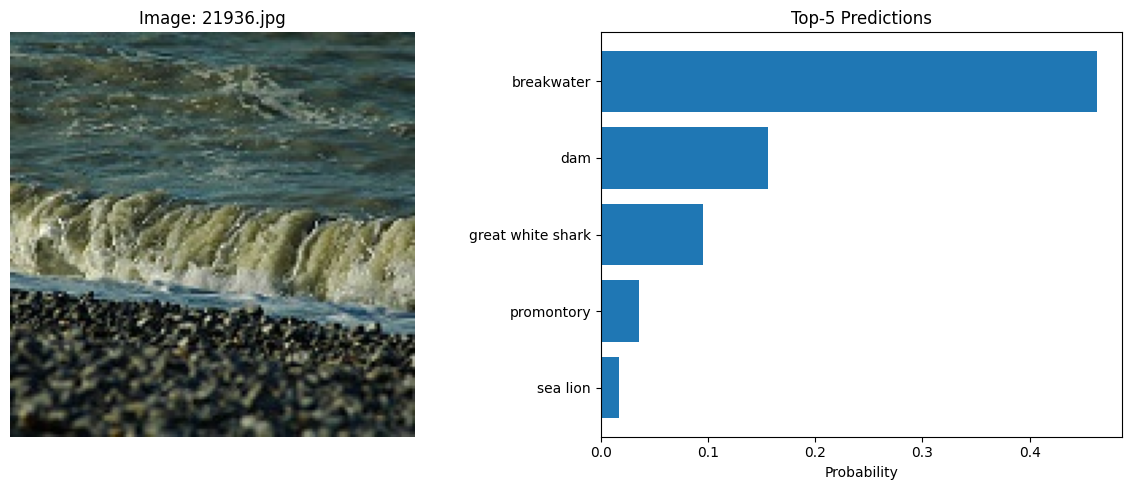

In [16]:
img, img_name = load_sample_image("sea")
preds = get_top5_predictions(model, preprocess, img, device, imagenet_classes)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(img)
axes[0].set_title(f"Image: {img_name}")
axes[0].axis("off")

class_names = [p[0] for p in preds]
probabilities  = [p[1]for p in preds]

axes[1].barh(class_names[::-1], probabilities[::-1])
axes[1].set_title("Top-5 Predictions")
axes[1].set_xlabel("Probability")

plt.tight_layout()
plt.savefig("outputs/warmup_inference_viz.png")
plt.show()

As this is a non-technical dashboard, this visualization can highlight the image, top predicted label, and if confidence is a cleared review threshold. A possible rule would be to send anything below .70 for a human reviewer.